# Exploratory Notebook

## Basic imports

In [3]:
%load_ext autoreload
%autoreload 2

import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from plotting_utils import plot_correlation_on_flatmap
from pathlib import Path

from load_data_sequences import create_data_sequences

sys.path.append('../')
from data_loading import (
    DataSequence, ContextManager, EmbeddingManager, 
    file_io, config, prepare_data
)
from data_loading.preprocessing import prepare_features

from main import perform_group_ridge

/home/simonee/miniconda3/envs/nonsense/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
root_dir = Path().resolve().parent

## Preparing the Data
Baseline Contexts and embeddings for subject 7, listening

In [3]:
stories_train = config.STORIES[:-1]
stories_val = config.STORIES[-1:]
mode = 'baseline'
subject = 'subject07'
use_keys = ['baseline'] + config.NUIS_LISTENING
use_keys_e1000 = ['english1000'] + config.NUIS_LISTENING
feature_path = root_dir/config.DEFAULT_FEATURE_PATH
response_path = root_dir/config.DEFAULT_RESPONSE_PATH

### Loading data sequences

In [4]:
ds = create_data_sequences(
    config.STORIES, 
    root_dir/config.DEFAULT_TRFILE_PATH,
    root_dir/config.DEFAULT_TEXTGRID_PATH,
    root_dir/config.DEFAULT_DATASEQ_PATH)

Loading TR files... ✓
Loading TextGrid textgrids... 

Loading TextGrid textgrids: 100%|██████████| 1/1 [00:00<00:00, 197.80it/s]


✓


Creating DataSequences:  36%|███▋      | 4/11 [00:00<00:00, 33.95it/s]


  Example ('alternateithicatom_en'):
    Words: 2175
    TRs: 358
    Bad words removed: 506
    First 10 words: ["there're", 'some', 'scientists', 'who', 'say', 'that', 'the', 'universe', 'that', 'we']


Creating DataSequences: 100%|██████████| 11/11 [00:00<00:00, 29.49it/s]


### Loading Contexts

In [6]:
context_mgr = ContextManager(root_dir/config.DEFAULT_CONTEXTS_FILE)
contexts = context_mgr.get_or_create_contexts(
    mode='baseline',
    stories=config.STORIES,
    dataseqs=ds,
    overwrite=False
)

In [8]:
contexts_zero = context_mgr.get_or_create_contexts(
    mode='zero',
    stories=config.STORIES,
    dataseqs=ds,
    overwrite=True
)

### Loading Embeddings

In [7]:
embedding_mgr = EmbeddingManager(root_dir/config.DEFAULT_EMBEDDINGS_FILE)
embeddings = embedding_mgr.get_or_create_embeddings(
    mode='baseline',
    stories=config.STORIES,
    dataseqs=ds,
    contexts=contexts,
    overwrite=False,
    verbose=False,
)

In [8]:
embeddings_zero = embedding_mgr.get_or_create_embeddings(
    mode='zero',
    stories=config.STORIES,
    dataseqs=ds,
    contexts=contexts_zero, 
    overwrite=False,
    verbose=False,
)

### Preparing Features and Responses

In [92]:
R_trn = file_io.load_responses('trn', response_path, [subject], 'listening', stories=stories_train)
R_val = file_io.load_responses('val', response_path, [subject], 'listening', stories=stories_val)

F_trn = file_io.load_features("trn", feature_path, stories=stories_train)
F_val = file_io.load_features("val", feature_path, stories=stories_val)

In [10]:
F_trn = prepare_features(F_trn, embeddings, mode, stories_train)
F_val = prepare_features(F_val, embeddings, mode, stories_val)

In [11]:
F_trn_zero = prepare_features(F_trn, embeddings_zero, 'zero', stories_train)
F_val_zero = prepare_features(F_val, embeddings_zero, 'zero', stories_val)

## Comparing contextual embeddings with Eng1000

### Creating Dataframes

In [14]:
df_eng1000 = pd.DataFrame(columns= ['mean r', 'mean r2', 'mean r_sig', 'score'], index=stories_train, data=0.0)
df_context = pd.DataFrame(columns= ['mean r', 'mean r2', 'mean r_sig', 'score'], index=stories_train, data=0.0)
df_zero = pd.DataFrame(columns= ['mean r', 'mean r2', 'mean r_sig', 'score'], index=stories_train, data=0.0)    

### Calculating results

In [91]:
for story in stories_train:
    print(f"Processing story: {story} with english1000 features")
    r, r2, r_sig, score = pipeline(
        R_trn[subject],
        R_val[subject],
        F_trn,
        F_val,
        [story],
        stories_val,
        use_keys_e1000,
    )
    df_eng1000.loc[story] = [np.nanmean(r), np.nanmean(r2), np.nanmean(r_sig), score]

Processing story: alternateithicatom_en with english1000 features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 33.79 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.
Processing story: avatar_en with english1000 features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 34.97 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.
Processing story: howtodraw_en with english1000 features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

...

 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 35.76 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.
Processing story: souls_en with english1000 features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 34.03 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.
Processing story: undertheinfluence_en with english1000 features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 32.77 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.


In [92]:
for story in stories_train:
    print(f"Processing story: {story} with contextual features")
    r, r2, r_sig, score = pipeline(
        R_trn[subject],
        R_val[subject],
        F_trn,
        F_val,
        [story],
        stories_val,
        use_keys,
    )
    df_context.loc[story] = [np.nanmean(r), np.nanmean(r2), np.nanmean(r_sig), score]

Processing story: alternateithicatom_en with contextual features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 33.13 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.
Processing story: avatar_en with contextual features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 34.65 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.
Processing story: howtodraw_en with contextual features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

...

 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 35.89 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.
Processing story: souls_en with contextual features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 33.62 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.
Processing story: undertheinfluence_en with contextual features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 32.86 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.


In [88]:
for story in stories_train:
    print(f"Processing story: {story} with zero context features")
    r, r2, r_sig, score = pipeline(
        R_trn[subject],
        R_val[subject],
        F_trn_zero,
        F_val_zero,
        [story],
        stories_val,
        ['zero'] + config.NUIS_LISTENING,
    )
    df_zero.loc[story] = [np.nanmean(r), np.nanmean(r2), np.nanmean(r_sig), score]

Processing story: alternateithicatom_en with zero context features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 34.29 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.
Processing story: avatar_en with zero context features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 34.85 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.
Processing story: howtodraw_en with zero context features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

...

 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 35.81 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.
Processing story: souls_en with zero context features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 34.09 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.
Processing story: undertheinfluence_en with zero context features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 32.94 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.


Plotting Scores

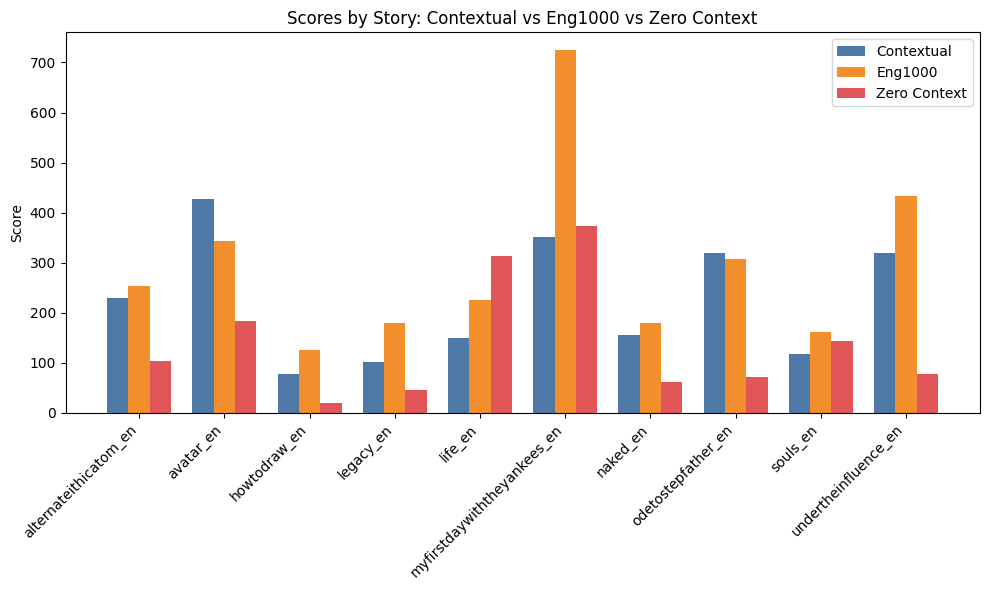

In [99]:
import matplotlib.pyplot as plt

# Colorblind-friendly palette (e.g., Tableau colors)
colors = ['#4E79A7', '#F28E2B', '#E15759']

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(stories_train))
width = 0.25

ax.bar(x - width, df_context['score'], width, label='Contextual', color=colors[0])
ax.bar(x, df_eng1000['score'], width, label='Eng1000', color=colors[1])
ax.bar(x + width, df_zero['score'], width, label='Zero Context', color=colors[2])

ax.set_xticks(x)
ax.set_xticklabels(stories_train, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('Scores by Story: Contextual vs Eng1000 vs Zero Context')
ax.legend()

plt.tight_layout()
plt.show()

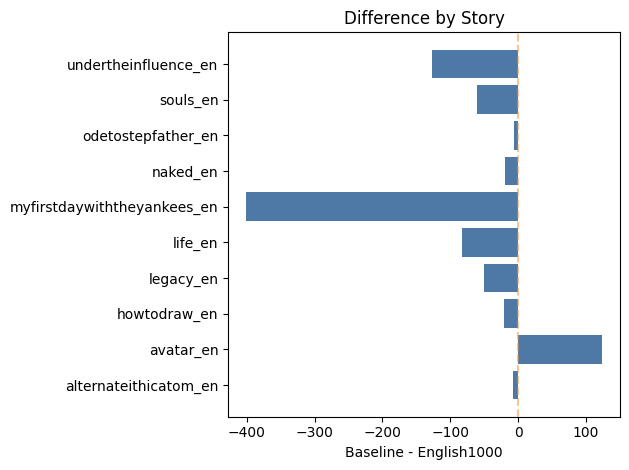

In [81]:
comparison = pd.DataFrame({
    'story': stories_train,
    'difference': df_context['score'] - df_eng1000['score'],
})

plt.barh(comparison['story'], comparison['difference'], color=colors[0])
plt.xlabel('Baseline - English1000')
plt.title('Difference by Story')
plt.axvline(0, color=colors[1], linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Correlation matrix:


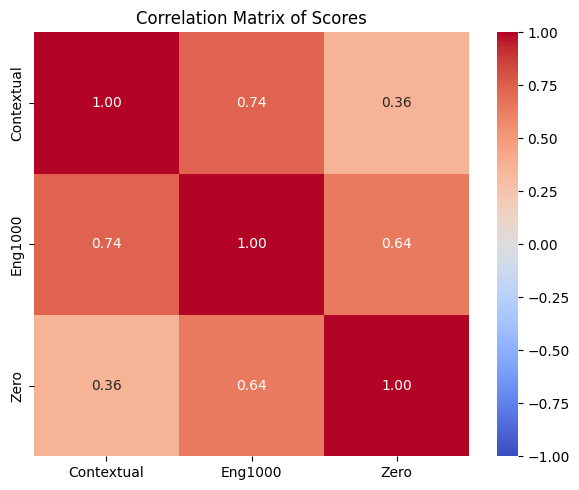

In [105]:
import seaborn as sns

df_scores = pd.DataFrame({
    'Contextual': df_context['score'],
    'Eng1000': df_eng1000['score'],
    'Zero': df_zero['score'],
}, index=stories_train)

print("Correlation matrix:")

corr = df_scores.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Scores')
plt.tight_layout()
plt.show()

## Partial analysis

Going in depth on outlier (my first day with the yankees) to see if there are differences in TR intervals between eng1000 and baseline 

In [77]:
def sliced_data(F_trn, F_val, R_trn, R_val, start = 0, end = 100):
    F_trn_trim = {story: {k: F_trn[story][k][start:min(end, F_trn[story][k].shape[0])] for k in F_trn[story].keys()} for story in stories_train}
    F_val_trim = {story: {k: F_val[story][k][start:min(end, F_val[story][k].shape[0])] for k in F_val[story].keys()} for story in stories_val}
    
    R_trn_trim = {story: R_trn[subject][story][start:min(end+5, R_trn[subject][story].shape[0])] for story in stories_train}
    R_val_trim = {story: R_val[subject][story][:,start:min(end+5, R_val[subject][story].shape[1])] for story in stories_val}
    return R_trn_trim, R_val_trim, F_trn_trim, F_val_trim

In [78]:
intervals = {'1:100': (0, 100), '1:200': (0, 200), '1:300': (0, 300), '1:end': (0, 3000)}

In [55]:
df_intervals = pd.DataFrame(columns = ['start', 'middle', 'end'], index = ['eng1000', 'context', 'zero'])

In [64]:
df_intervals = df_intervals.rename(columns={'start': '1:100', 'middle': '1:200', 'end': '1:300'})
story_name = config.STORIES[5]
df_intervals['1:end'] = [
    df_eng1000.loc[story_name, 'score'],
    df_context.loc[story_name, 'score'],
    df_zero.loc[story_name, 'score'],
]
df_intervals

,1:100,1:200,1:300,1:end
eng1000,1070.33606,1.491817,8.187354,1031.045410
context,1175.739258,21.037268,97.431038,1168.998779
zero,750.352356,0.0,20.509533,0.000000


In [85]:
for interval_name, (start, end) in intervals.items():
    print(f"Processing interval: {interval_name} ({start}-{end})")
    
    R_trn_trim, R_val_trim, F_trn_trim, F_val_trim = sliced_data(F_trn, F_val, R_trn, R_val, start, end)
    
    print(f"Processing story: {config.STORIES[5]} with english1000 features")
    r, r2, r_sig, score = pipeline(
        R_trn_trim,
        R_val_trim,
        F_trn_trim,
        F_val_trim,
        [config.STORIES[5]],
        stories_val,
        use_keys_e1000,
    )
    df_intervals.loc['eng1000', interval_name] = score
    
    print(f"Processing story: {config.STORIES[5]} with contextual features")
    r, r2, r_sig, score = pipeline(
        R_trn_trim,
        R_val_trim,
        F_trn_trim,
        F_val_trim,
        [config.STORIES[5]],
        stories_val,
        use_keys,
    )
    df_intervals.loc['context', interval_name] = score

    print(f"Processing story: {config.STORIES[5]} with zero context features")
    r, r2, r_sig, score = pipeline(
        R_trn_trim,
        R_val_trim,
        F_trn_trim,
        F_val_trim,
        [config.STORIES[5]],
        stories_val,
        ['zero'] + config.NUIS_LISTENING,
    )
    df_intervals.loc['zero', interval_name] = score

Processing interval: 1:200 (0-200)
Processing story: myfirstdaywiththeyankees_en with english1000 features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses... ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[                                        ] 0% | 0.00 sec | 100 random sampling with cv | 

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


[........................................] 100% | 31.42 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.
Processing story: myfirstdaywiththeyankees_en with contextual features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses... ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[                                        ] 0% | 0.00 sec | 100 random sampling with cv | 

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


[........................................] 100% | 31.58 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.
Processing story: myfirstdaywiththeyankees_en with zero context features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses... ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[                                        ] 0% | 0.00 sec | 100 random sampling with cv | 

...

 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 34.58 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.
Processing story: myfirstdaywiththeyankees_en with contextual features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 34.44 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.
Processing story: myfirstdaywiththeyankees_en with zero context features
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses...

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


 ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 34.65 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Applying FDR correction... ✓
Pipeline execution complete.


In [86]:
df_intervals

,1:100,1:200,1:300,1:end
eng1000,1070.33606,275.625519,211.866318,752.441040
context,1175.739258,206.903778,152.877777,365.333557
zero,750.352356,182.761841,132.199234,373.144135


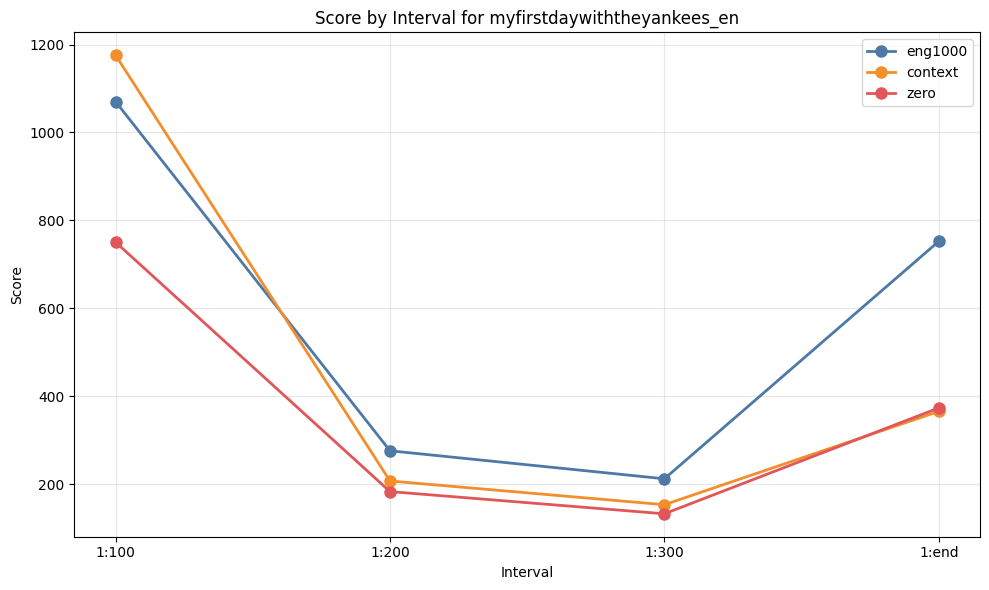

In [87]:
colors = ['#4E79A7', '#F28E2B', '#E15759']
fig, ax = plt.subplots(figsize=(10, 6))

x_labels = df_intervals.columns
x_pos = np.arange(len(x_labels))

for i, (model_name, row) in enumerate(df_intervals.iterrows()):
    ax.plot(x_pos, row.values, marker='o', label=model_name, color=colors[i], linewidth=2, markersize=8)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Interval')
ax.set_ylabel('Score')
ax.set_title(f'Score by Interval for {story_name}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [117]:
progression_baseline = {}
progression_eng1000 = {}

In [118]:
for story in [1, 5, 7]:
    progression_baseline[story] = []
    progression_eng1000[story] = []
    for i in np.linspace(100, 150, 6, dtype=int):
        R_trn_trim, R_val_trim, F_trn_trim, F_val_trim = sliced_data(F_trn, F_val, R_trn, R_val, 0, i)
        r, r2, r_sig, score = pipeline(
            R_trn_trim,
            R_val_trim,
            F_trn_trim,
            F_val_trim,
            [config.STORIES[story]],
            stories_val,
            use_keys_e1000,
        )
        progression_eng1000[story].append(score)
        
        r, r2, r_sig, score = pipeline(
            R_trn_trim,
            R_val_trim,
            F_trn_trim,
            F_val_trim,
            [config.STORIES[story]],
            stories_val,
            use_keys,
        )
        progression_baseline[story].append(score)
        

Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses... ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[                                        ] 0% | 0.00 sec | 100 random sampling with cv | 

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


[........................................] 100% | 31.92 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations...

/home/simonee/miniconda3/envs/nonsense/lib/python3.11/site-packages/himalaya/scoring.py:149: UserWarning: y_true has to be zero-mean over samples to compute the split r2 scores.
  warnings.warn(


 ✓
Applying FDR correction... ✓
Pipeline execution complete.
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses... ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[                                        ] 0% | 0.00 sec | 100 random sampling with cv | 

...

 ✓
Applying FDR correction... ✓
Pipeline execution complete.
Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses... ✓
Building feature groups... ✓
Performing Group Ridge CV...Fitting MultipleKernelRidgeCV model...
[                                        ] 0% | 0.00 sec | 100 random sampling with cv | 

/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


[........................................] 100% | 31.47 sec | 100 random sampling with cv | 
Model fitting complete.
 ✓
Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations...

/home/simonee/miniconda3/envs/nonsense/lib/python3.11/site-packages/himalaya/scoring.py:149: UserWarning: y_true has to be zero-mean over samples to compute the split r2 scores.
  warnings.warn(


 ✓
Applying FDR correction... ✓
Pipeline execution complete.


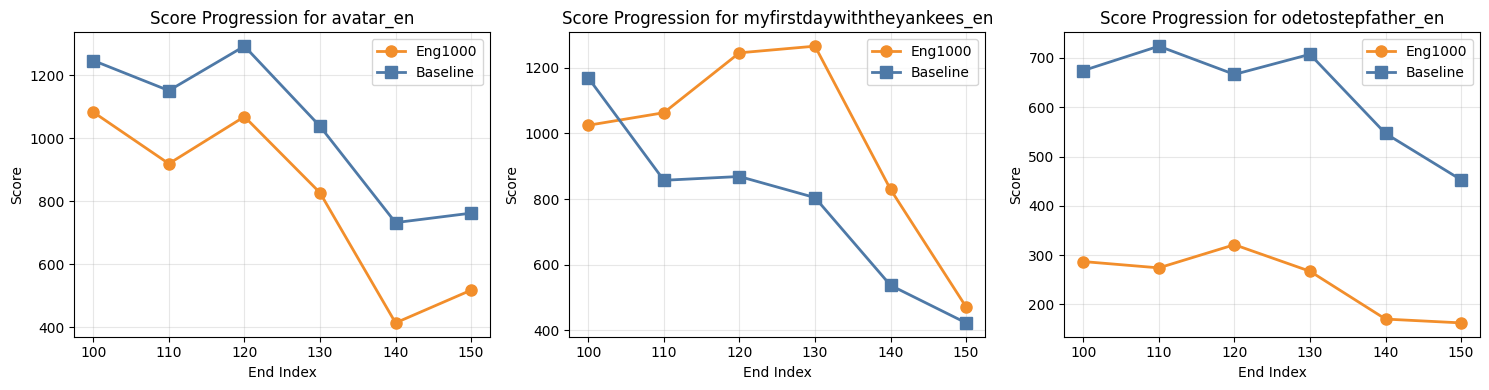

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, story in enumerate([1, 5, 7]):
    ax = axes[idx]
    intervals = sorted(progression_eng1000[story])
    
    ax.plot(np.linspace(100, 150, 6), progression_eng1000[story], marker='o', label='Eng1000', color=colors[1], linewidth=2, markersize=8)
    ax.plot(np.linspace(100, 150, 6), progression_baseline[story], marker='s', label='Baseline', color=colors[0], linewidth=2, markersize=8)
    
    ax.set_xlabel('End Index')
    ax.set_ylabel('Score')
    ax.set_title(f'Score Progression for {config.STORIES[story]}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [115]:
progression = dict(sorted(progression.items()))

In [110]:
progression_baseline

{100: np.float32(1208.4125),
 120: np.float32(870.4602),
 130: np.float32(779.1845),
 132: np.float32(790.072),
 134: np.float32(758.6212),
 136: np.float32(711.54846),
 138: np.float32(593.8092),
 140: np.float32(563.2933),
 150: np.float32(401.5521),
 200: np.float32(214.90239)}

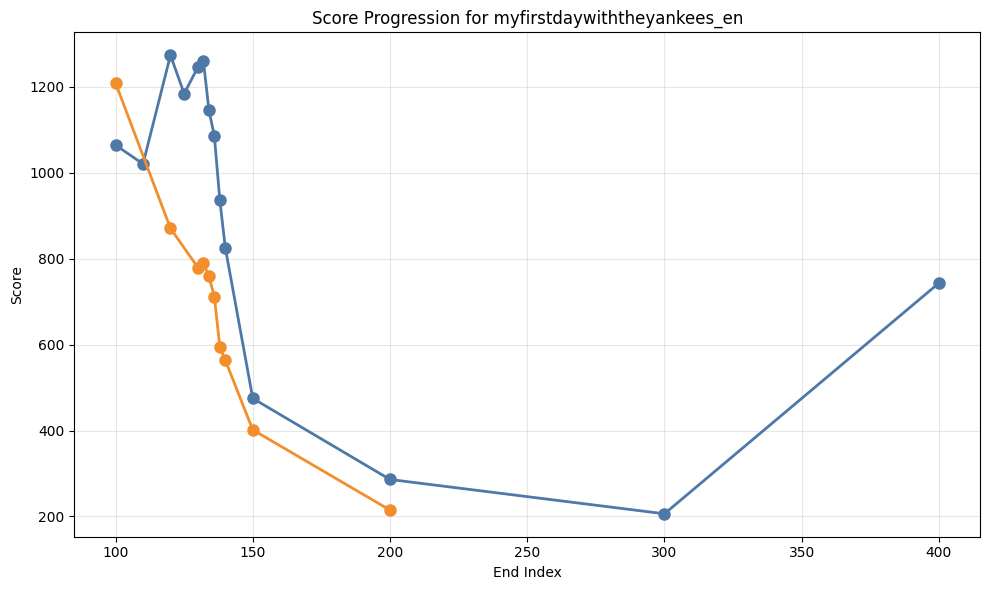

In [111]:
plt.figure(figsize=(10, 6))
plt.plot(list(progression.keys()), list(progression.values()), marker='o', color=colors[0], linewidth=2, markersize=8)
plt.plot(list(progression_baseline.keys()), list(progression_baseline.values()), marker='o', color=colors[1], linewidth=2, markersize=8)    
plt.xlabel('End Index')
plt.ylabel('Score')
plt.title(f'Score Progression for {story_name}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [114]:
np.linspace(100, 150, 6, dtype=int)

array([100, 110, 120, 130, 140, 150])

## Full run

### Eng1000

In [73]:
X_trn, Y_trn, X_val, Y_val, groups, story_ids = prepare_data(
    R_trn[subject],
    R_val[subject],
    F_trn,
    F_val,
    stories_train,
    stories_val,
    use_keys_e1000,
)

Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses... ✓
Building feature groups... ✓


/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


In [81]:
results_e1000 = perform_group_ridge(
    X_trn, 
    Y_trn, 
    groups, 
    story_ids, 
    np.logspace(-10, 10, 21), 
    use_keys_e1000
)

Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 247.68 sec | 100 random sampling with cv | 
Model fitting complete.


In [84]:
r_e1000, r2_e1000, pvalues_e1000 = results_processing(results_e1000, X_val, X_trn, Y_val, groups, use_keys_e1000)

Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Performing permutation tests...

100%|██████████| 5000/5000 [02:41<00:00, 30.95it/s]


 ✓


In [90]:
fdr_e1000 = apply_fdr_correction(pvalues_e1000)

Applying FDR correction...[0.     0.     0.     ... 0.4376 0.1724 0.5018]
[0.         0.         0.         ... 0.4376     0.1864     0.49899998]
 ✓


In [91]:
r_sig_e1000 = np.zeros_like(r_e1000)
r_sig_e1000[fdr_e1000['r']['included_voxels_indices']] = r_e1000[fdr_e1000['r']['included_voxels_indices']]

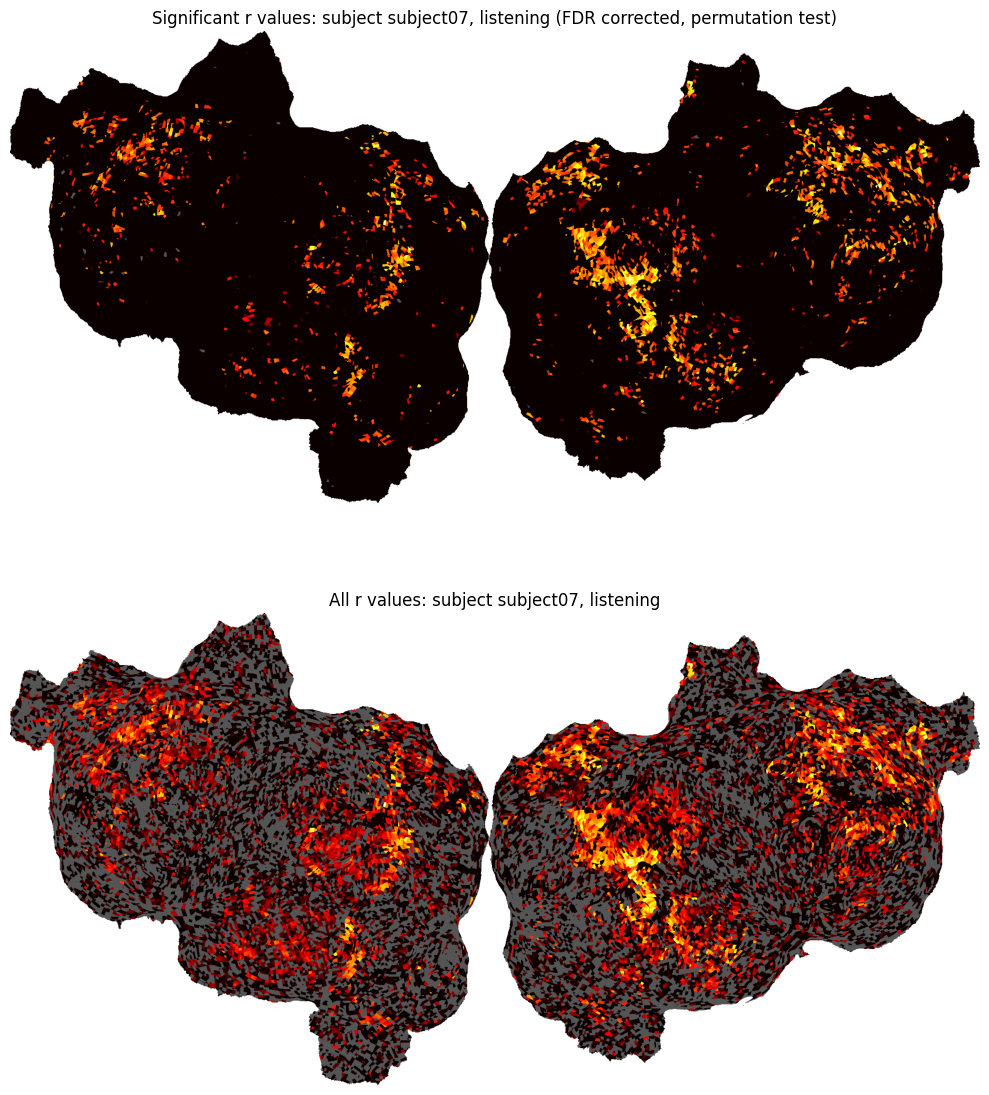

In [92]:
plot_correlation_on_flatmap(
    subject,
    'listening',
    'baseline',
    r_e1000,
    r_sig_e1000,
    root_dir/config.DEFAULT_MAPPER_PATH,
    False,
    False
)

In [95]:
np.nanmean(r_e1000[fdr['r']['included_voxels_indices']])

np.float32(0.15492712)

### Contextual

In [62]:
X_trn, Y_trn, X_val, Y_val, groups, story_ids = prepare_data(
    R_trn[subject],
    R_val[subject],
    F_trn,
    F_val,
    stories_train,
    stories_val,
    use_keys
)

Stacking and delaying features for training... ✓
Stacking and delaying features for validation... ✓
Stacking responses... ✓
Building feature groups... ✓


/mnt/antares_raid/home/simonee/nonsense/data_loading/__init__.py:170: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val[stories_val[0]].mean(0)[5:])


In [63]:
results = perform_group_ridge(
    X_trn, 
    Y_trn, 
    groups, 
    story_ids, 
    np.logspace(-10, 10, 21), 
    use_keys
)

Fitting MultipleKernelRidgeCV model...
[........................................] 100% | 254.60 sec | 100 random sampling with cv | 
Model fitting complete.


In [24]:
np.savez(
    root_dir / 'data_slices_baseline.npz',
    results=results,
    X_trn=X_trn,
    Y_trn=Y_trn,
    X_val=X_val,
    Y_val=Y_val,
    groups=groups,
    story_ids=story_ids
)

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [64]:
r, r2, pvalues = results_processing(results, X_val, X_trn, Y_val, groups, use_keys)

Processing results... ✓
Computing kernels for validation... ✓
Calculating correlations... ✓
Performing permutation tests...

100%|██████████| 5000/5000 [03:33<00:00, 23.47it/s]


 ✓


In [65]:
fdr = apply_fdr_correction(pvalues)

Applying FDR correction...[0.         0.         0.         ... 0.46699998 0.4488     0.3538    ]
[0.     0.     0.     ... 0.4624 0.4502 0.3478]
 ✓


In [66]:
r_sig = np.zeros_like(r)
r_sig[fdr['r']['included_voxels_indices']] = r[fdr['r']['included_voxels_indices']]

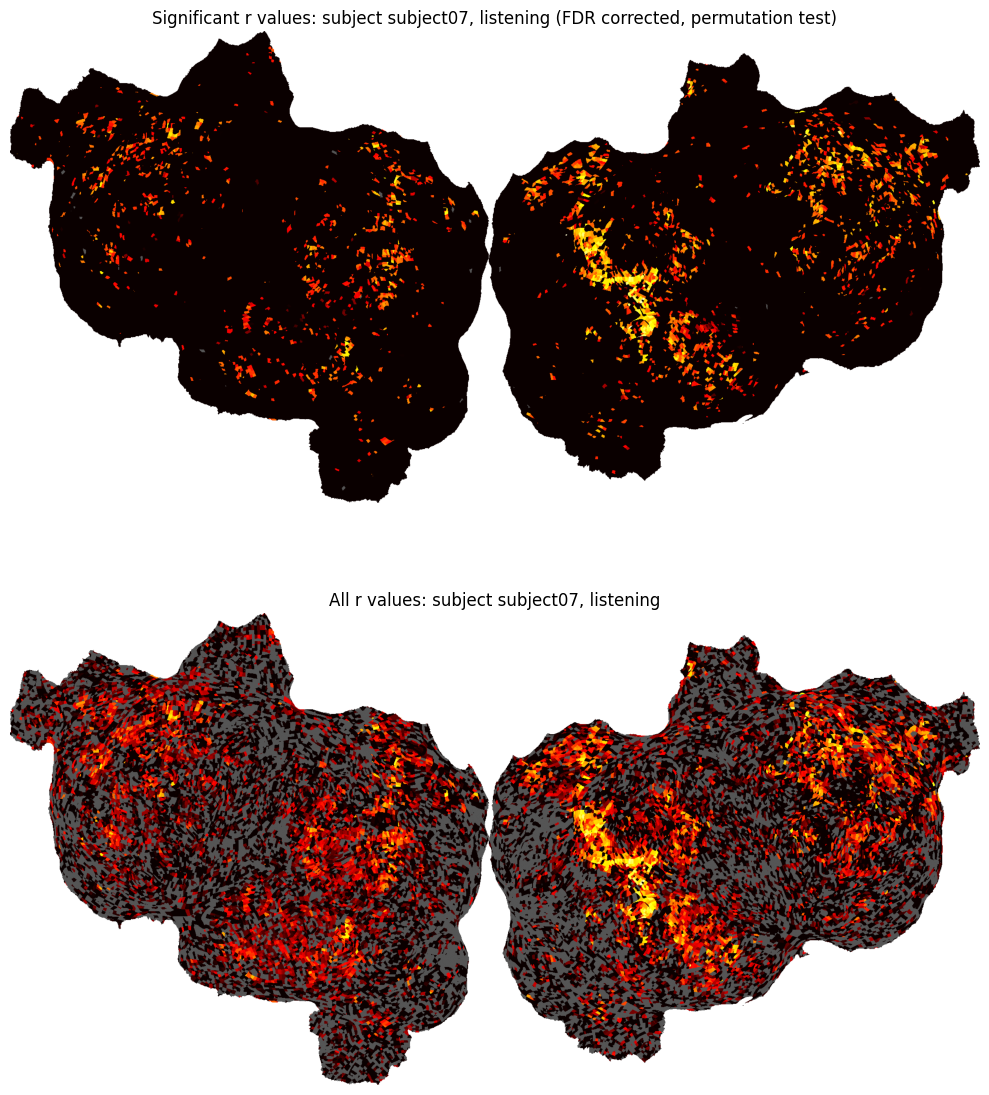

In [82]:
plot_correlation_on_flatmap(
    subject,
    'listening',
    'baseline',
    r,
    r_sig,
    root_dir/config.DEFAULT_MAPPER_PATH,
    False,
    False
)

In [83]:
np.nanmean(r_sig)

np.float32(0.18608789)

In [96]:
np.nanmean(r)

np.float32(0.01899432)

In [97]:
np.nanmean(r_e1000)

np.float32(0.017439388)

## PEAKS AND VALLEYS

In [8]:
from main import apply_fdr_correction
def contrast_result(res1, res2):
    contrast = {}
    contrast['r'] = res1['r'] - res2['r']
    contrast['r2'] = res1['r2'] - res2['r2']
    contrast['pvalues'] = np.minimum(res1['pvalues'], res2['pvalues'])
    contrast['fdr'] = apply_fdr_correction(contrast['pvalues'])
    return contrast

In [12]:
for mode in ['english1000', 'baseline', 'valley', 'peak']:
    res_mode[mode] = np.load(root_dir/config.DEFAULT_OUTPUT_PATH/'results'/f'subject07_listening_{mode}.npy', allow_pickle=True).item()
    print(f"Mean r for {mode}: {np.nanmean(res_mode[mode]['r'][res_mode[mode]['fdr']['r']['included_voxels_indices']])}")

Mean r for english1000: 0.1889563500881195
Mean r for baseline: 0.18262368440628052
Mean r for valley: 0.186214879155159
Mean r for peak: 0.17661456763744354


np.float32(967.45654)

In [47]:
context = np.load(root_dir/config.DEFAULT_CONTEXTS_FILE, allow_pickle=True)

In [52]:
valley = context['valley'].item()

In [53]:
valley = {k: np.char.replace(v, 'UNK', 'XXXX') for k, v in valley.items()}

In [54]:
valley

{'alternateithicatom_en': array(['', "there're", "there're XXXX", ...,
        'XXXX hang around him and to haunt XXXX like XXXX',
        'hang around him XXXX to haunt XXXX like XXXX hungry',
        'around him XXXX to haunt XXXX like XXXX hungry ghost'],
       shape=(2175,), dtype='<U78'),
 'avatar_en': array(['', 'tom', 'tom XXXX', ...,
        'XXXX XXXX and i got up XXXX i held her',
        'XXXX and i got up XXXX i held XXXX thank',
        'and i got up XXXX i held XXXX thank XXXX'],
       shape=(1464,), dtype='<U68'),
 'howtodraw_en': array(['', 'where', 'where XXXX', ...,
        'XXXX toss the keys head to art XXXX XXXX join',
        'toss the keys head XXXX art XXXX XXXX join my',
        'the keys head XXXX art XXXX XXXX join my tribe'],
       shape=(1965,), dtype='<U78'),
 'legacy_en': array(['', 'so', 'so XXXX', ...,
        'steiner XXXX which really suits XXXX much XXXX and uh',
        "XXXX which really suits XXXX much XXXX and uh we're",
        "which really 

In [55]:
np.savez(
            root_dir/config.DEFAULT_CONTEXTS_FILE,
            **{'valley': valley},
        )